In [1]:
# Import functions from preprocessing.py
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch


# Add the path to the src directory
sys.path.append(os.path.abspath(os.path.join('..', 'data')))
from generation import generate_data, partition_domain_into_regions


In [2]:
# Import functions from generation.py
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from trainer import trainer, compute_q_phi

In [3]:
B = 9 # Number of regions
n_i = 5  # Number of locations per region

# Generate data
y, x, w, e, s, region_assignments = generate_data(B, n_i, sigmasq = 5, length_scale=1.0, nu=0.5, seed=50, beta_true=2, tau_true=1)

In [4]:
torch.eye(n_i).dtype

torch.float32

In [7]:
def test_trainer():
    torch.manual_seed(50)  # For reproducibility

    # Tiny toy setup
    n_iter = 30
    n_blocks = B
    n_locations = n_i
    n_samples = n_blocks  # Same as number of blocks

    # Random toy data for X and Y
    X = torch.tensor(x, dtype=torch.float32).reshape(n_samples, n_locations)
    Y = torch.tensor(y, dtype=torch.float32).reshape(n_samples, n_locations)

    # Generate (n_blocks * n_locations) 2D coordinates
    total_points = n_blocks * n_locations
    locations = torch.tensor(s,dtype=torch.float32)

    # Compute distance matrix from locations
    x_norm = (locations ** 2).sum(dim=1).view(-1, 1)
    Dist = x_norm + x_norm.T - 2.0 * (locations @ locations.T)
    Dist = torch.sqrt(torch.clamp(Dist, min=1e-10))  # Ensure numerical stability

    # Set optional args
    n_steps = 10
    n_phi_samples = 20
    n_piX_sample = 20
    tau_X = 0.1
    tau_S = 0.1
    n_piS_sample = 20
    
    

    print("\n=== Running Minimal Trainer Test ===\n")

    results = trainer(
        n_iter=n_iter,
        n_blocks=n_blocks,
        n_locations=n_locations,
        X=X,
        Y=Y,
        Dist=Dist,
        n_steps=n_steps,
        n_phi_samples=n_phi_samples,
        n_piX_sample=n_piX_sample,
        tau_X=tau_X, tau_S=tau_S,
        n_piS_sample=n_piS_sample
    )

    print("\n=== Final Output ===")
    (mu_W, Sigma_W, M_X_star, V_X_star,
     M_S_star, V_S_star, mu_lambda_beta,
     sigmasq_lambda_beta, lambda_a1,
     lambda_b1, lambda_a2, lambda_b2) = results

    print("\nmu_W:\n", mu_W)
    print("\nSigma_W:\n", Sigma_W)
    print("\nM_X_star:\n", M_X_star)
    print("\nV_X_star:\n", V_X_star)
    print("\nM_S_star:\n", M_S_star)
    print("\nV_S_star:\n", V_S_star)
    print("\nmu_lambda_beta:", mu_lambda_beta)
    print("sigmasq_lambda_beta:", sigmasq_lambda_beta)
    print("lambda_a1:", lambda_a1, "lambda_b1:", lambda_b1)
    print("lambda_a2:", lambda_a2, "lambda_b2:", lambda_b2)

if __name__ == "__main__":
    test_trainer()



=== Running Minimal Trainer Test ===

mean_Rphi_inv: tensor([[ 3.7961e+01, -1.1379e+01, -2.6626e+01,  ...,  1.0089e-02,
          2.3835e-05,  3.3481e-02],
        [-1.1379e+01,  4.5152e+01,  2.0632e+00,  ...,  6.0164e-03,
         -2.4945e-04,  1.7771e-02],
        [-2.6626e+01,  2.0632e+00,  3.2520e+01,  ...,  1.7626e-02,
         -1.1460e-03,  4.0811e-02],
        ...,
        [ 1.0082e-02,  6.0271e-03,  1.7625e-02,  ...,  3.4915e+01,
         -2.0428e+01, -1.2334e+00],
        [ 3.6610e-05, -2.6269e-04, -1.1543e-03,  ..., -2.0427e+01,
          4.0536e+01, -1.6789e+01],
        [ 3.3487e-02,  1.7773e-02,  4.0808e-02,  ..., -1.2335e+00,
         -1.6789e+01,  2.1027e+01]])
mu_W: tensor([[ 2.1024,  1.9995,  1.9546,  1.9190,  1.5125],
        [-0.1721,  0.2585,  0.7705,  0.0518, -0.5471],
        [-1.2247, -1.6518, -1.5436, -2.0224, -1.6439],
        [-0.7133, -1.1222, -1.1446, -1.1475, -1.2799],
        [-1.6923, -1.4949, -1.0695, -1.3216, -1.0157],
        [-2.6299, -2.3288, -2.721

KeyboardInterrupt: 

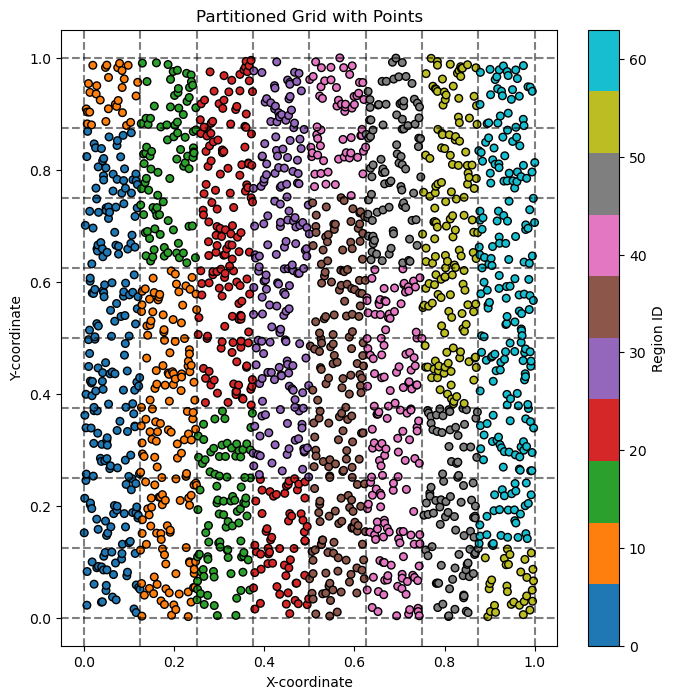

In [ ]:
# Plot the grid and points
grid_size = int(np.ceil(np.sqrt(B)))

# Create the plot
plt.figure(figsize=(8, 8))

# Plot the grid
x_divisions = np.linspace(0, 1, grid_size + 1)
y_divisions = np.linspace(0, 1, grid_size + 1)
for xx in x_divisions:
    plt.axvline(x=xx, color='k', linestyle='--', alpha=0.5)
for yy in y_divisions:
    plt.axhline(y=yy, color='k', linestyle='--', alpha=0.5)

# Plot the points
plt.scatter(s[:, 0], s[:, 1], c=region_assignments, cmap='tab10', marker='o', edgecolor='k', s=30)

# Title and labels
plt.title("Partitioned Grid with Points")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.colorbar(label='Region ID')

plt.show()

In [11]:
y.shape, x.shape, s.shape, region_assignments.shape, w.shape, e.shape

((1920,), (1920, 1), (1920, 2), (1920,), (1920,), (1920,))

In [12]:
# Optimizing using Numpy
import numpy as np
from scipy.optimize import minimize
from sklearn.gaussian_process.kernels import Matern
from scipy.spatial.distance import cdist

# Function to compute the NNGP covariance matrix using locations s
def compute_K_NN(s, K, num_neighbors):
    n = s.shape[0]
    K_NN = np.zeros_like(K)
    
    # Calculate pairwise distances between the locations s
    distances = cdist(s, s)
    
    for i in range(n):
        # Find the indices of the nearest neighbors based on location distances
        neighbor_indices = np.argsort(distances[i])[1:num_neighbors+1]
        K_NN[i, neighbor_indices] = K[i, neighbor_indices]
        K_NN[neighbor_indices, i] = K[neighbor_indices, i]
        
    return K_NN

def nngp_log_likelihood(y, s, X, beta, K, tausq, num_neighbors):
    n = len(y)
    K_NN = K # Use location s here
    K_NN_noise = K_NN 
    
    try:
        L = np.linalg.cholesky(K_NN_noise)
        log_det = 2 * np.sum(np.log(np.diagonal(L)))
    except np.linalg.LinAlgError:
        return -np.inf
    
    residual = y - X @ beta
    solve_term = np.linalg.solve(L.T, np.linalg.solve(L, residual))
    quadratic_term = residual.T @ solve_term
    
    log_likelihood = -0.5 * (n * np.log(2 * np.pi) + log_det + quadratic_term)
    return log_likelihood

# Function to compute the NNGP log-likelihood for given nu, length_scale, tausq, and beta
def nngp_log_likelihood_with_params(params, s, X, y, num_neighbors):
    # Extract parameters from the input
    n = len(y)
    nu = params[0]
    length_scale = params[1]
    tausq = params[2]
    sigmasq= params[3]
    beta = params[4:]
    
    # Compute the full covariance matrix K using the skMatern kernel
    matern_kernel = sigmasq * Matern(length_scale=length_scale, nu=0.5)
    K = matern_kernel(s) + tausq * np.eye(n) # Calculate the kernel matrix using location s
    
    # Compute the NNGP log-likelihood
    return -nngp_log_likelihood(y, s, X, beta, K, tausq, num_neighbors)  # Negative for minimization


# Initial guess for parameters: [nu, length_scale, tausq, beta_1, ..., beta_p]
params_init = np.array([0.5,0.3, 0.3, 2] + list(np.zeros(1)))
num_neighbors= 3

bounds = [(0.499, 0.501), (0.1, 10.0), (0.1, 10.0), (0.1, 10.0)] + [(None, None)] * (params_init.shape[0] - 4)

# Optimization with bounds
result = minimize(
    nngp_log_likelihood_with_params,
    params_init,
    args=(s, x, y, num_neighbors),
    method='L-BFGS-B',bounds=bounds
)

# Output the optimized parameters
print("Optimized Parameters:")
print("nu:", result.x[0])
print("length_scale:", result.x[1])
print("sigmasq/length_scale:", result.x[3]/result.x[1])
print("tausq:", result.x[2])
print("sigmasq:", result.x[3])
print("beta:", result.x[4:])
print("Log-Likelihood:", -result.fun)


Optimized Parameters:
nu: 0.5
length_scale: 0.9619261006845268
sigmasq/length_scale: 4.1487380018484705
tausq: 1.009418351749861
sigmasq: 3.990779368879814
beta: [1.97324716]
Log-Likelihood: -2929.945782905404


In [15]:
# Optimising using PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.gaussian_process.kernels import Matern
from scipy.spatial.distance import cdist
import numpy as np
import gpytorch
import torch
import torch.special

def exponential_kernel(X1, X2, length_scale=1.0, sigma=1.0):
    """
    Computes the Matérn covariance function with ν = 1/2 (exponential covariance).

    Args:
        X1 (torch.Tensor): Input tensor of shape (n, d).
        X2 (torch.Tensor): Input tensor of shape (m, d).
        rho (float): Characteristic lengthscale parameter.
        sigma (float): Scaling factor (variance term).

    Returns:
        torch.Tensor: Covariance matrix of shape (n, m).
    """
    dists = torch.cdist(X1, X2, p=2)  # Compute pairwise Euclidean distances
    return sigma * torch.exp(-dists / length_scale)

def compute_regionwise_covariance(s, region_assignments, sigmasq, length_scale, nu=0.5, tausq=1):
    """
    Computes the variance-covariance matrix for the averaged spatial GP process w_ibar.

    Parameters:
    s: (N, 2) tensor of spatial locations
    region_assignments: (N,) tensor assigning each location to a region
    sigma_sq: scalar, variance of the GP
    length_scale: scalar, length scale of the Matern kernel
    nu: scalar, smoothness parameter of the Matern kernel
    tausq: scalar, variance of the noise term

    Returns:
    cov_matrix: (B, B) tensor, variance-covariance matrix of region-averaged w
    """
    unique_regions = torch.unique(region_assignments)
    B = len(unique_regions)
    
    # Compute full covariance matrix for all locations using Matern kernel
    #scaled_s = s / length_scale
    matern_kernel = exponential_kernel(s, s, length_scale=length_scale)
    K = sigmasq * matern_kernel  # Scale by variance
    
    # Initialize variance-covariance matrix
    cov_matrix = torch.zeros((B, B))
    
    # Create a binary indicator matrix of shape (num_samples, num_regions)
    region_mask = torch.stack([(region_assignments == region).float() for region in unique_regions], dim=1)

    # Compute region sizes (n_i for each region)
    region_sizes = region_mask.sum(dim=0, keepdim=True)  # Shape: (1, num_regions)

    # Compute the covariance matrix efficiently
    # Equivalent to looping over i, j but using matrix multiplication
    region_sums = region_mask.T @ K @ region_mask  # Shape: (num_regions, num_regions)
    cov_matrix = region_sums / (region_sizes.T @ region_sizes)  # Element-wise division

    # Ensure numerical stability by avoiding division by zero
    cov_matrix[region_sizes.T @ region_sizes == 0] = 0
    cov_matrix

    # Add diagonal tausq / n_i term
    diag_tau_term = torch.diag(tausq / region_sizes)* torch.eye(B)  # Shape: (num_regions, num_regions)
    cov_matrix += diag_tau_term
        
    return cov_matrix


# PyTorch Module for optimizing NNGP parameters
class NNGPModel(nn.Module):
    def __init__(self, input_dim, device='cpu'):
        super(NNGPModel, self).__init__()
        self.device = device

        # Learnable parameters
        self.nu = nn.Parameter(torch.tensor(0.5, device=device))
        self.length_scale = nn.Parameter(torch.tensor(1.5, device=device))
        self.tausq = nn.Parameter(torch.tensor(1.0, device=device))
        self.sigmasq = nn.Parameter(torch.tensor(2.0, device=device))
        self.beta = nn.Parameter(torch.zeros(input_dim, device=device))
    
    def nngp_log_likelihood(self, y, s, X, beta, K):
        n = y.shape[0]
        K_NN = K  # Use precomputed covariance
        K_NN_noise = K_NN
        log_det = torch.logdet(K_NN_noise)
        
        residual = y - X @ beta
        quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
        log_likelihood = -0.5 * (log_det + quadratic_term)
        return log_likelihood   
        

    def forward(self, s, X, y):
        n = y.shape[0]
        # Compute covariance matrix using Matern kernel
        K = self.sigmasq * exponential_kernel(s, s, length_scale=self.length_scale) + self.tausq * torch.eye(n, device=self.device)
        return -self.nngp_log_likelihood(y, s, X, self.beta, K)

In [16]:
# Sample Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 1
# num_neighbors= 3

y = torch.tensor(y, dtype=torch.float32, device=device)
x = torch.tensor(x, dtype=torch.float32, device=device)
w = torch.tensor(w, dtype=torch.float32, device=device)
e = torch.tensor(e, dtype=torch.float32, device=device)
s = torch.tensor(s, dtype=torch.float32, device=device)
region_assignments = torch.tensor(region_assignments, dtype=torch.int64, device=device)  # Region indices as integers


/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_88961/3520268286.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.float32, device=device)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_88961/3520268286.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=device)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_88961/3520268286.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w = torch.tensor(w, dtype=torch.float32, device=

In [18]:
# PyTorch Module for optimizing block-level covariance
class NNGPArealModel(nn.Module):
    def __init__(self, input_dim, device='cpu'):
        super(NNGPArealModel, self).__init__()
        self.device = device

        # Learnable parameters
        self.nu = nn.Parameter(torch.tensor(0.5, device=device))
        self.length_scale = nn.Parameter(torch.tensor(1.5, device=device))
        self.tausq = nn.Parameter(torch.tensor(1.0, device=device))
        self.sigmasq = nn.Parameter(torch.tensor(2.0, device=device))
        self.beta = nn.Parameter(torch.zeros(input_dim, device=device))
    
    def nngp_log_likelihood(self, y, s, X, beta, K):
        n = y.shape[0]
        K_NN = K  # Use precomputed covariance
        K_NN_noise = K_NN
        log_det = torch.logdet(K_NN_noise)
        
        residual = y - X @ beta
        quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
        log_likelihood = -0.5 * (log_det + quadratic_term)
        return log_likelihood   
        

    def forward(self, s, region_assignments, X, y):
        # Compute covariance matrix using Matern kernel
        K = compute_regionwise_covariance(s, region_assignments, self.sigmasq, self.length_scale, self.nu, self.tausq)
        return -self.nngp_log_likelihood(y, s, X, self.beta, K)

In [19]:

# Initialize and optimize the model
model = NNGPModel(input_dim, device).to(device)
# optimizer = optim.LBFGS(model.parameters(), lr=0.1, max_iter=100, line_search_fn="strong_wolfe")
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)

for i in tqdm(range(1000)):
    optimizer.zero_grad()
    loss = model(s, x, y)
    loss.backward()
    optimizer.step()
    
    # with torch.no_grad():
    #     model.length_scale.clamp_(min = .0001)
    #     model.tausq.clamp_(min = .0001)
    #     model.sigmasq.clamp_(min = .0001)
    #     model.nu.clamp_(min = .0001)
        
    if i % 100 == 0:
        print(f"Iteration {i}, Loss: {loss.item()}")
        print("nu:", model.nu.item())
        print("length_scale:", model.length_scale.item())
        print("sigma_sq/length_scale:", model.sigmasq.item()/(model.length_scale.item()))
        print("tausq:", model.tausq.item())
        print("sigmasq:", model.sigmasq.item())
        print("beta:", model.beta.detach().cpu().numpy())
        print("=="*20)

# # Optimization step
# def closure():
#     optimizer.zero_grad()
#     loss = model(s, x, y, num_neighbors)
#     loss.backward()
#     return loss

# optimizer.step(closure)
# with torch.no_grad():
#     print("Optimized Parameters:")
#     print("nu:", model.nu.item())
#     print("length_scale:", model.length_scale.item())
#     print("tausq:", model.tausq.item())
#     print("sigmasq:", model.sigmasq.item())
    

# # Output the optimized parameters
# print("Optimized Parameters:")
# print("nu:", model.nu.item())
# print("length_scale:", model.length_scale.item())
# print("tausq:", model.tausq.item())
# print("sigmasq:", model.sigmasq.item())
# print("beta:", model.beta.detach().cpu().numpy())

  0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_88961/1771537102.py:96: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729646995093/work/aten/src/ATen/native/TensorShape.cpp:3687.)
  quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
  0%|          | 4/1000 [00:00<00:58, 16.89it/s]

Iteration 0, Loss: 1485.1890869140625
nu: 0.5
length_scale: 1.4898500442504883
sigma_sq/length_scale: 1.348994796510865
tausq: 1.0098999738693237
sigmasq: 2.0097999572753906
beta: [0.01]


 10%|█         | 104/1000 [00:05<00:47, 18.84it/s]

Iteration 100, Loss: 1250.413818359375
nu: 0.5
length_scale: 0.7517000436782837
sigma_sq/length_scale: 3.4324026910817595
tausq: 1.1837313175201416
sigmasq: 2.580137252807617
beta: [0.85713017]


 20%|██        | 204/1000 [00:10<00:40, 19.44it/s]

...

 80%|████████  | 804/1000 [00:43<00:11, 17.66it/s]

Iteration 800, Loss: 1165.72265625
nu: 0.5
length_scale: 0.7130929231643677
sigma_sq/length_scale: 4.151662602432656
tausq: 1.0090728998184204
sigmasq: 2.9605212211608887
beta: [1.9610796]


 90%|█████████ | 904/1000 [00:49<00:05, 17.96it/s]

Iteration 900, Loss: 1165.7015380859375
nu: 0.5
length_scale: 0.7268809676170349
sigma_sq/length_scale: 4.152215995373201
tausq: 1.0090880393981934
sigmasq: 3.0181667804718018
beta: [1.9621687]


100%|██████████| 1000/1000 [00:54<00:00, 18.23it/s]


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = 1
# num_neighbors= 3

y = torch.tensor(y, dtype=torch.float32, device=device)
x = torch.tensor(x, dtype=torch.float32, device=device)
w = torch.tensor(w, dtype=torch.float32, device=device)
e = torch.tensor(e, dtype=torch.float32, device=device)
s = torch.tensor(s, dtype=torch.float32, device=device)
region_assignments = torch.tensor(region_assignments, dtype=torch.int64, device=device)  # Region indices as integers



# Compute region-wise averages directly
unique_regions = torch.unique(region_assignments)
B = len(unique_regions)

ybar = torch.zeros(B, device=y.device)
xbar = torch.zeros(B, input_dim, device=x.device)

for i, region in enumerate(unique_regions):
    # Get indices for the current region
    indices = torch.where(region_assignments == region)[0]
    
    # Compute region-wise averages for y and x
    ybar[i] = torch.mean(y[indices])
    xbar[i] = torch.mean(x[indices], dim=0)

# Print results
print("Region-wise y averages (ybar):", ybar)
print("Region-wise x averages (xbar):", xbar)

# Initialize and optimize the model
model = NNGPArealModel(input_dim, device).to(device)
# optimizer = optim.LBFGS(model.parameters(), lr=0.1, max_iter=100, line_search_fn="strong_wolfe")
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)

for i in tqdm(range(1000)):
    optimizer.zero_grad()
    loss = model(s, region_assignments, xbar, ybar)
    loss.backward()
    optimizer.step()
    
    #with torch.no_grad():
    #     model.length_scale.clamp_(min = .0001)
    #  model.tausq.clamp_(min = .0001)
    #     model.sigmasq.clamp_(min = .0001)
    #     model.nu.clamp_(min = .0001)
        
    if i % 100 == 0:
        print(f"Iteration {i}, Loss: {loss.item()}")
        print("nu:", model.nu.item())
        print("length_scale:", model.length_scale.item())
        print("sigma_sq/length_scale:", model.sigmasq.item()/(model.length_scale.item()))
        print("tausq:", model.tausq.item())
        print("sigmasq:", model.sigmasq.item())
        print("beta:", model.beta.detach().cpu().numpy())
        print("=="*20)


/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_88961/3822512223.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.float32, device=device)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_88961/3822512223.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=device)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_88961/3822512223.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  w = torch.tensor(w, dtype=torch.float32, device=

Region-wise y averages (ybar): tensor([-2.3263, -2.1643, -1.9768, -0.8178, -1.2709, -1.0218,  0.2983,  0.4482,
        -2.3736, -2.2691, -2.2868, -2.1177, -1.8234, -1.8514, -1.1051, -0.5189,
        -2.1308, -2.2749, -2.0215, -2.0390, -1.4717, -1.7448, -0.9783, -1.5078,
        -1.2203, -1.5215, -2.3882, -2.5829, -2.4367, -2.3871, -1.7290, -1.8166,
        -1.0816, -2.1245, -1.8803, -2.0532, -1.8534, -1.4004, -1.4769, -1.4273,
        -1.7254, -2.1406, -1.5271, -1.9422, -0.5266,  0.0817, -0.1053, -0.3026,
        -2.7477, -1.7381, -0.9159, -0.5548, -0.0894,  0.3037,  1.0473, -0.0492,
        -1.0410, -1.5916,  0.0886,  0.8054,  0.1909,  1.0387,  0.9737, -0.8906])
Region-wise x averages (xbar): tensor([[0.5232],
        [0.4755],
        [0.5214],
        [0.5412],
        [0.4825],
        [0.5092],
        [0.4666],
        [0.5086],
        [0.5912],
        [0.5762],
        [0.4955],
        [0.4781],
        [0.4918],
        [0.5260],
        [0.4164],
        [0.5091],
        [

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 5/1000 [00:00<00:24, 41.07it/s]

Iteration 0, Loss: 6.558803558349609
nu: 0.5
length_scale: 1.4898500442504883
sigma_sq/length_scale: 1.348994796510865
tausq: 1.0098999738693237
sigmasq: 2.0097999572753906
beta: [0.01]


...

 81%|████████  | 812/1000 [00:12<00:02, 68.01it/s]

Iteration 800, Loss: -5.335872650146484
nu: 0.5
length_scale: 0.7228341102600098
sigma_sq/length_scale: 3.702458550834393
tausq: 0.9239360690116882
sigmasq: 2.6762633323669434
beta: [0.98263633]


 91%|█████████ | 912/1000 [00:13<00:01, 70.36it/s]

Iteration 900, Loss: -5.338191986083984
nu: 0.5
length_scale: 0.727281928062439
sigma_sq/length_scale: 3.716959987595238
tausq: 0.9063123464584351
sigmasq: 2.703277826309204
beta: [0.99489707]


100%|██████████| 1000/1000 [00:14<00:00, 67.84it/s]


In [ ]:
# Jumble x and s within regions
x_jumbled_within_regions = torch.zeros_like(x)
s_jumbled_within_regions = torch.zeros_like(s)
perm_mat_all_x = []
perm_mat_all_s = []

for i, region in enumerate(unique_regions):
    # Get indices for the current region
    indices = torch.where(region_assignments == region)[0]
    
    # Shuffle the indices within the region
    perm_x = torch.randperm(indices.size(0))
    perm_s = torch.randperm(indices.size(0))
    perm_mat_all_x.append(perm_x)
    perm_mat_all_s.append(perm_s)
    
    # Assign the shuffled values back
    x_jumbled_within_regions[indices] = x[indices[perm_x]]
    s_jumbled_within_regions[indices] = s[indices[perm_s]]

# Print the jumbled data
print("Jumbled x within regions:", x_jumbled_within_regions)
print("Jumbled s within regions:", s_jumbled_within_regions)

Jumbled x within regions: tensor([[0.9226],
        [0.8615],
        [0.5442],
        ...,
        [0.6812],
        [0.9403],
        [0.9872]])
Jumbled s within regions: tensor([[0.0618, 0.1173],
        [0.0495, 0.0577],
        [0.0714, 0.0319],
        ...,
        [0.9303, 0.9853],
        [0.9175, 0.9446],
        [0.9898, 0.9474]])


In [34]:
ybar_jumbled = ybar
xbar_jumbled = torch.zeros(B, input_dim, device=x.device)

for i, region in enumerate(unique_regions):
    # Get indices for the current region
    indices = torch.where(region_assignments == region)[0]
    
    # Compute region-wise averages for y and x
    ybar[i] = torch.mean(y[indices])
    xbar_jumbled[i] = torch.mean(x_jumbled_within_regions[indices], dim=0)

In [37]:
# Initialize and optimize the model
model = NNGPArealModel(input_dim, device).to(device)
#optimizer = optim.LBFGS(model.parameters(), lr=0.1, max_iter=100, line_search_fn="strong_wolfe")
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.01)

for i in tqdm(range(1000)):
    optimizer.zero_grad()
    loss = model(s_jumbled_within_regions, region_assignments, xbar_jumbled, ybar)
    loss.backward()
    optimizer.step()
    
    #with torch.no_grad():
    #     model.length_scale.clamp_(min = .0001)
    #  model.tausq.clamp_(min = .0001)
    #     model.sigmasq.clamp_(min = .0001)
    #     model.nu.clamp_(min = .0001)
        
    if i % 100 == 0:
        print(f"Iteration {i}, Loss: {loss.item()}")
        print("nu:", model.nu.item())
        print("length_scale:", model.length_scale.item())
        print("sigma_sq/length_scale:", model.sigmasq.item()/(model.length_scale.item()))
        print("tausq:", model.tausq.item())
        print("sigmasq:", model.sigmasq.item())
        print("beta:", model.beta.detach().cpu().numpy())
        print("=="*20)


  1%|          | 12/1000 [00:00<00:16, 59.31it/s]

Iteration 0, Loss: 6.558876037597656
nu: 0.5
length_scale: 1.4898500442504883
sigma_sq/length_scale: 1.348994796510865
tausq: 1.0098999738693237
sigmasq: 2.0097999572753906
beta: [0.01]


 11%|█         | 108/1000 [00:01<00:12, 70.58it/s]

Iteration 100, Loss: -5.183036804199219
nu: 0.5
length_scale: 0.8009564876556396
sigma_sq/length_scale: 3.185783408320695
tausq: 1.4675533771514893
sigmasq: 2.5516738891601562
beta: [0.6727382]


 21%|██        | 212/1000 [00:03<00:11, 71.43it/s]

...

 81%|████████  | 809/1000 [00:11<00:02, 71.41it/s]

Iteration 800, Loss: -5.335823059082031
nu: 0.5
length_scale: 0.7228339910507202
sigma_sq/length_scale: 3.7024591614413356
tausq: 0.9239338636398315
sigmasq: 2.6762633323669434
beta: [0.98263574]


 91%|█████████▏| 913/1000 [00:12<00:01, 71.72it/s]

Iteration 900, Loss: -5.3381500244140625
nu: 0.5
length_scale: 0.7272816300392151
sigma_sq/length_scale: 3.7169631498273077
tausq: 0.9063107371330261
sigmasq: 2.7032790184020996
beta: [0.99489754]


100%|██████████| 1000/1000 [00:14<00:00, 70.26it/s]


In [39]:
from scipy.optimize import linear_sum_assignment

# Store initial estimates of parameters
initial_beta = model.beta.detach().cpu().numpy()

# Initialize a list to store the permutation matrices for each region
perm_matrices = []

# Iterate over each region
for region in unique_regions:
    # Get indices for the current region
    indices = torch.where(region_assignments == region)[0]
    
    # Extract y and x_jumbled_within_regions for the current region
    y_region = y[indices].cpu().numpy()
    x_region = x_jumbled_within_regions[indices].cpu().numpy()
    
    # Compute the cost matrix based on the absolute difference
    cost_matrix = np.abs(y_region[:, None] - x_region @ initial_beta)
    
    # Solve the assignment problem using the Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Create the permutation matrix
    perm_matrix = np.zeros_like(cost_matrix, dtype=int)
    perm_matrix[row_ind, col_ind] = 1
    
    # Store the permutation matrix
    perm_matrices.append(perm_matrix)

# Print the first few permutation matrices as an example
for i, perm_matrix in enumerate(perm_matrices[:3]):
    print(f"Permutation matrix for region {unique_regions[i].item()}:\n", perm_matrix)

Permutation matrix for region 0:
 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0

array([25, 19, 17, 26,  8, 28,  9,  7, 27, 20,  6, 15, 22, 21, 10, 13, 16,
       11, 23, 14, 24,  0, 18,  1,  2,  3, 12,  4,  5, 29])

In [43]:
# Calculate w_jumbled_with_regions using the matching from perm_matrices
w_jumbled_with_regions = torch.zeros_like(y)

for i, region in enumerate(unique_regions):
    # Get indices for the current region
    indices = torch.where(region_assignments == region)[0]
    
    # Extract the permutation matrix for the current region
    perm_matrix = torch.tensor(perm_matrices[i], dtype=torch.float32, device=y.device)
    
    # Apply the matching to x and beta
    x_matched = perm_matrix @ x[indices]
    w_jumbled_with_regions[indices] = y[indices] - x_matched @ model.beta

# Print the result
print("w_jumbled_with_regions:", w_jumbled_with_regions)

w_jumbled_with_regions: tensor([-2.1169, -0.7945, -2.1824,  ..., -0.5439, -2.0535, -1.0545],
       grad_fn=<IndexPutBackward0>)


Ordered s_jumbled_within_regions: tensor([[0.0065, 0.0223],
        [0.0071, 0.0825],
        [0.0182, 0.0996],
        ...,
        [0.9848, 0.9481],
        [0.9898, 0.9474],
        [0.9943, 0.9400]])
Matched w: tensor([-2.8617, -3.6913, -3.0145,  ..., -1.0545, -2.0535, -0.8300])


Ordered s_jumbled_within_regions: tensor([[0.0065, 0.0223],
        [0.0071, 0.0825],
        [0.0182, 0.0996],
        ...,
        [0.9848, 0.9481],
        [0.9898, 0.9474],
        [0.9943, 0.9400]])


In [58]:
s_jumbled_within_regions.size()

torch.Size([1920, 2])

In [53]:
from scipy.optimize import linear_sum_assignment

# Generate simulate_w from the full s_jumbled_within_regions
length_scale = model.length_scale.item()
sigmasq = model.sigmasq.item()
tausq = model.tausq.item()

# Calculate the kernel matrix for s_jumbled_within_regions
kernel_matrix_jumbled = exponential_kernel(s_jumbled_within_regions, s_jumbled_within_regions, length_scale=length_scale, sigma=sigmasq) + tausq * torch.eye(s_jumbled_within_regions.shape[0], device=s_jumbled_within_regions.device)

# Simulate w using Multivariate Normal
simulate_w = torch.distributions.MultivariateNormal(torch.zeros(s_jumbled_within_regions.shape[0], device=s_jumbled_within_regions.device), kernel_matrix_jumbled).sample()

# Initialize a list to store the permutation matrices for s_jumbled_within_regions
perm_matrices_s = []

# Match simulate_w with w_jumbled_with_regions obtained in the previous step
for region in unique_regions:
    indices = torch.where(region_assignments == region)[0]
    
    # Extract simulate_w and w_jumbled_with_regions for the current region
    simulate_w_region = simulate_w[indices].detach().cpu().numpy()
    w_jumbled_region = w_jumbled_with_regions[indices].detach().cpu().numpy()
    
    # Compute the cost matrix based on the absolute difference
    cost_matrix = np.abs(simulate_w_region[:, None] - w_jumbled_region)
    
    # Solve the assignment problem using the Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    # Create the permutation matrix
    perm_matrix = np.zeros_like(cost_matrix, dtype=int)
    perm_matrix[row_ind, col_ind] = 1
    
    # Store the permutation matrix
    perm_matrices_s.append(perm_matrix)

# Print the first few permutation matrices as an example
for i, perm_matrix in enumerate(perm_matrices_s[:3]):
    print(f"Permutation matrix for region {unique_regions[i].item()}:\n", perm_matrix)


Permutation matrix for region 0:
 [[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0

0.7325127720832825

In [63]:
cost_matrix = np.abs(simulate_w_region[:, None] - w_jumbled_region)
cost_matrix.shape

(30, 30)

In [ ]:
cost_matrix.shape

In [67]:
# Initialize tensors for matched y, x, and s
y1 = torch.zeros_like(y)
x1 = torch.zeros_like(x)
s1 = torch.zeros_like(s)

# Match y, x, and s based on learned permutations
for i, region in enumerate(unique_regions):
    # Get indices for the current region
    indices = torch.where(region_assignments == region)[0]
    
    # Extract the permutation matrix for the current region
    perm_matrix_x = torch.tensor(perm_matrices[i], dtype=torch.float32, device=y.device)
    perm_matrix_s = torch.tensor(perm_matrices_s[i], dtype=torch.float32, device=y.device)
    
    # Apply the matching to x and s
    x_matched = perm_matrix_x @ x[indices]
    s_matched = perm_matrix_s.T @ s[indices]
    
    # Assign matched values to y1, x1, and s1
    y1[indices] = y[indices]
    x1[indices] = x_matched
    s1[indices] = s_matched

# Print the results
print("Matched y1:", y1)
print("Matched x1:", x1)
print("Matched s1:", s1)

Matched y1: tensor([-2.0182, -0.5304, -2.0820,  ...,  0.1410, -1.6395, -0.8776])
Matched x1: tensor([[0.0982],
        [0.2627],
        [0.0998],
        ...,
        [0.6812],
        [0.4117],
        [0.1760]])
Matched s1: tensor([[0.0225, 0.0599],
        [0.0843, 0.1145],
        [0.0285, 0.0893],
        ...,
        [0.9211, 0.9784],
        [0.9612, 0.9628],
        [0.9234, 0.8960]])


In [68]:
# Initialize and optimize the model
model2 = NNGPModel(input_dim, device).to(device)
# optimizer = optim.LBFGS(model.parameters(), lr=0.1, max_iter=100, line_search_fn="strong_wolfe")
optimizer = optim.AdamW(model2.parameters(), lr=0.01, weight_decay=0.01)

for i in tqdm(range(1000)):
    optimizer.zero_grad()
    loss = model2(s1, x1, y1)
    loss.backward()
    optimizer.step()
    
    # with torch.no_grad():
    #     model.length_scale.clamp_(min = .0001)
    #     model.tausq.clamp_(min = .0001)
    #     model.sigmasq.clamp_(min = .0001)
    #     model.nu.clamp_(min = .0001)
        
    if i % 100 == 0:
        print(f"Iteration {i}, Loss: {loss.item()}")
        print("nu:", model2.nu.item())
        print("length_scale:", model2.length_scale.item())
        print("sigma_sq/length_scale:", model2.sigmasq.item()/(model2.length_scale.item()))
        print("tausq:", model2.tausq.item())
        print("sigmasq:", model2.sigmasq.item())
        print("beta:", model2.beta.detach().cpu().numpy())
        print("=="*20)

  0%|          | 4/1000 [00:00<00:54, 18.17it/s]

Iteration 0, Loss: 1649.7066650390625
nu: 0.5
length_scale: 1.4898500442504883
sigma_sq/length_scale: 1.348994796510865
tausq: 1.0098999738693237
sigmasq: 2.0097999572753906
beta: [0.01]


 10%|█         | 104/1000 [00:05<00:46, 19.46it/s]

Iteration 100, Loss: 1518.9892578125
nu: 0.5
length_scale: 0.8625237345695496
sigma_sq/length_scale: 2.897133644862978
tausq: 1.5225502252578735
sigmasq: 2.4988465309143066
beta: [0.06494002]


 20%|██        | 204/1000 [00:10<00:41, 19.15it/s]

...

 80%|████████  | 804/1000 [00:42<00:10, 18.30it/s]

Iteration 800, Loss: 1518.03173828125
nu: 0.5
length_scale: 0.7606654167175293
sigma_sq/length_scale: 2.6196994353795784
tausq: 1.592516303062439
sigmasq: 1.992714762687683
beta: [0.06349625]


 90%|█████████ | 904/1000 [00:48<00:05, 18.10it/s]

Iteration 900, Loss: 1518.0244140625
nu: 0.5
length_scale: 0.7372550964355469
sigma_sq/length_scale: 2.621543641697755
tausq: 1.5927091836929321
sigmasq: 1.932746410369873
beta: [0.06314303]


100%|██████████| 1000/1000 [00:54<00:00, 18.46it/s]


In [7]:
import torch

# Example tensors
M_S_star = torch.tensor([[1, 2], [3, 4]])  # Shape [2, 2]
mu_W = torch.tensor([[5, 6], [7, 8], [9, 10]])      # Shape [2, 2] (batch size = 2)
# Y = torch.tensor([[10, 20], [30, 40]])     # Shape [2, 2]

# Compute residual
residual = torch.einsum('ij,bj->bi', M_S_star, mu_W)

print(residual)

tensor([[17, 39],
        [23, 53],
        [29, 67]])


NameError: name 'torch' is not defined

tensor([[17, 39],
        [23, 53],
        [29, 67]])